In [1]:
pip install langgraph langchain_core langchain_groq tavily-python langchain gradio langchain_community

Note: you may need to restart the kernel to use updated packages.


In [11]:
from typing import Dict, TypedDict, Optional
from langgraph.graph import StateGraph, END
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq
from langchain.tools import Tool

from IPython.display import display, Image
from langchain_core.runnables.graph import MermaidDrawMethod
from dotenv import load_dotenv
import os
import uuid

import sys

from langchain_community.tools.tavily_search import TavilySearchResults
from tavily import TavilyClient
from langchain.schema.runnable import RunnableLambda
from langgraph.graph import StateGraph, END



# Load environment variables and set OpenAI API key
load_dotenv()
tavily_client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))
os.environ["GROQ_API_KEY"] = os.getenv('GROQ_API_KEY')

In [16]:
class State(TypedDict):
    query: list
    response: Optional[str]
    approved: Optional[bool]
    memory: list
    # budget: Optional[int]
    results: Optional[dict]

In [9]:
model_name = "llama-3.1-8b-instant"

History report generator: System that can search for articles / papers on specific historical topics. Can possibly look into pulling public records for historical information.

In [17]:

search_node = RunnableLambda(lambda query: tavily_search.run(query))


def search(state: State) -> State:
    """search for average house price, cost of living, commute time in area."""
    """agent outputs a bunch of viable real estate in the given budget/county/crime rate/commute time etc"""

    prompt = ChatPromptTemplate.from_template(
        "Find me properties using the user data:\n\n User query: {query}"
    )

    chain = prompt | ChatGroq(model=model_name, temperature=0)
    refined_query = chain.invoke({"query": query}).content

    search_results = tavily_client.search(query=query,
    include_domains=["zillow.com"],
    max_results=10) 
    
    state["memory"].append(state["query"]) 
    state["memory"].append(search_results) 
    
    return {"results": search_results, "memory": state["memory"]}

def price_house(state: State) -> State:
    """Extract average house price from Zillow results."""
    text = str(state["results"])
    chain = ChatGroq(model=model_name, temperature=0)
    response = chain.invoke(f"Based on this data, what is the average house price?\n\n{text}").content
    state["response"] = response
    return state

def price_living(state: State) -> State:
    """Estimate cost of living from context."""
    query = f"average cost of living in {state['query']}"
    result = tavily_client.search(query=query, max_results=5)
    state["memory"].append(result)
    return {"results": result}


# def budget(state: State) -> State:
#     """Filter listings by user’s max budget."""
#     max_budget = state["budget"]
#     filtered = [
#         r for r in state["results"]["results"]
#         if "price" in r["content"].lower() and int("".join([c for c in r["content"] if c.isdigit()])) <= max_budget
#     ]
#     state["results"] = {"results": filtered}
#     return state

def crime_rate(state: State) -> State:
    """Find recent crime statistics for area."""
    query = f"crime rate in {state['query']}"
    result = tavily_client.search(query=query, max_results=5)
    state["memory"].append(result)
    return {"results": result}


def commute_times(state: State) -> State:
    """Search for average commute times to amenities."""
    query = f"average commute time to schools and stores in {state['query']}"
    result = tavily_client.search(query=query, max_results=5)
    state["memory"].append(result)
    return {"results": result}


In [18]:
graph = StateGraph(State)

# Add your function nodes
graph.add_node("search", search)
graph.add_node("price_house", price_house)
graph.add_node("price_living", price_living)
graph.add_node("crime_rate", crime_rate)
graph.add_node("commute_times", commute_times)

# Define execution order
graph.add_edge("search", "price_house")
graph.add_edge("price_house", "price_living")
graph.add_edge("price_living", "crime_rate")
graph.add_edge("crime_rate", "commute_times")
graph.add_edge("commute_times", END)

# Set entry point
graph.set_entry_point("search")

# Compile it into a runnable chain
graph = graph.compile()

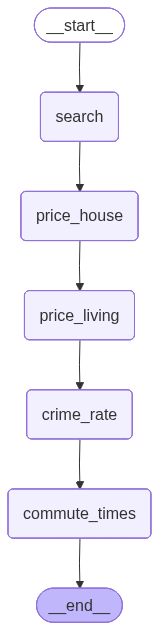

In [19]:
display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

Tool-Calling functionality:

As explored previously, the agent should use tools for performing research and get relevant context from the web, or have a vector database with a large volume of documents to retrieve relevant knowledge.



User Interface and Agent Response:

Final response of the agent should be well structured into a report (pdf format).

A user interface where the user can ask a query and get the response from the LLM, a report that can be downloaded or viewed in the interface.

In [6]:
import streamlit as st
import random
import time

st.write("Streamlit loves LLMs! 🤖 [Build your own chat app](https://docs.streamlit.io/develop/tutorials/llms/build-conversational-apps) in minutes, then make it powerful by adding images, dataframes, or even input widgets to the chat.")

st.caption("Note that this demo app isn't actually connected to any LLMs. Those are expensive ;)")

# Initialize chat history
if "messages" not in st.session_state:
    st.session_state.messages = [{"role": "assistant", "content": "Let's start chatting! 👇"}]

# Display chat messages from history on app rerun
for message in st.session_state.messages:
    with st.chat_message(message["role"]):
        st.markdown(message["content"])

# Accept user input
if prompt := st.chat_input("What is up?"):
    # Add user message to chat history
    st.session_state.messages.append({"role": "user", "content": prompt})
    # Display user message in chat message container
    with st.chat_message("user"):
        st.markdown(prompt)

    # Display assistant response in chat message container
    with st.chat_message("assistant"):
        message_placeholder = st.empty()
        full_response = ""
        assistant_response = random.choice(
            [
                "Hello there! How can I assist you today?",
                "Hi, human! Is there anything I can help you with?",
                "Do you need help?",
            ]
        )
        # Simulate stream of response with milliseconds delay
        for chunk in assistant_response.split():
            full_response += chunk + " "
            time.sleep(0.05)
            # Add a blinking cursor to simulate typing
            message_placeholder.markdown(full_response + "▌")
        message_placeholder.markdown(full_response)
    # Add assistant response to chat history
    st.session_state.messages.append({"role": "assistant", "content": full_response})


2025-10-14 16:15:35.078 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-14 16:15:35.363 
  command:

    streamlit run C:\Users\ericm\anaconda3\envs\langchain\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-10-14 16:15:35.363 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-14 16:15:35.364 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-14 16:15:35.364 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-14 16:15:35.365 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-14 16:15:35.366 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-14 16:15:35.366 Thread '